# Lab 2 - Comitês (Ensembles)

Classificadores: **Random Forest**, **AdaBoost** e **XGBoost**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lab2_utils import carregar_dados, avaliar_modelo, logar_mlflow, iniciar_run

X_train, y_train, X_test, y_test = carregar_dados()

Dados carregados (gerados em 2026-06-24 15:43)
  X_train: (440832, 11)  |  X_test: (64374, 11)
  Features: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Contract Length', 'Total Spend', 'Last Interaction', 'Subscription Type_Premium', 'Subscription Type_Standard']
  Churn rate treino: 0.567  |  teste: 0.474


## Random Forest


=== RandomForest ===
              precision    recall  f1-score   support

Não cancelou       0.98      0.07      0.13     33881
    Cancelou       0.49      1.00      0.66     30493

    accuracy                           0.51     64374
   macro avg       0.73      0.53      0.40     64374
weighted avg       0.75      0.51      0.38     64374

Kappa: 0.0664


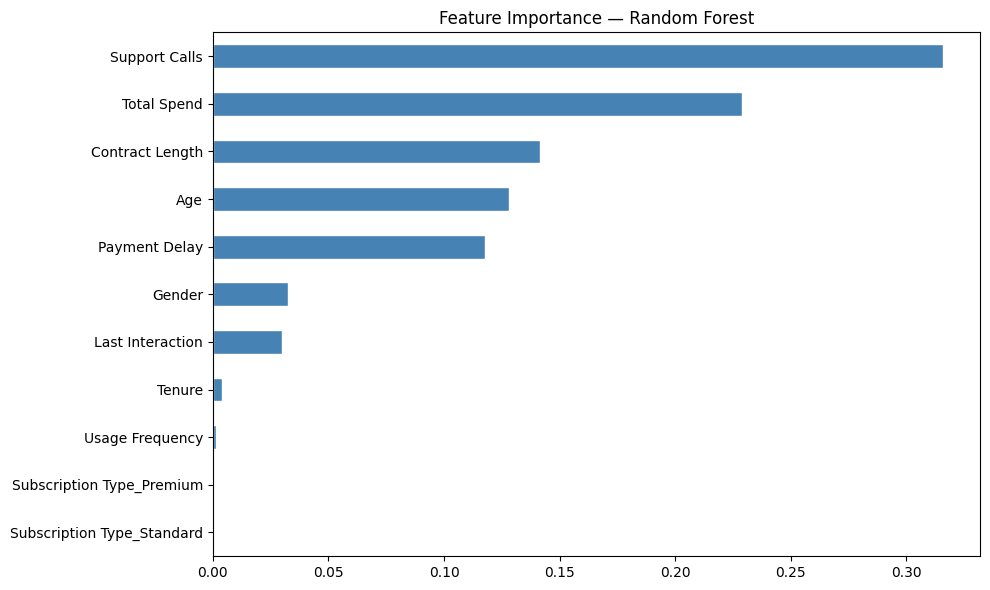

🏃 View run RandomForest at: http://127.0.0.1:5000/#/experiments/1/runs/e224c9d32e0d4d6e8addbc102aa9be01
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [2]:
# ─── Random Forest ──────────────────────────────────────────────
# Melhoria: class_weight='balanced', max_depth=10 para regularizar,
# n_estimators=200 (suficiente, evita overfitting de floresta muito grande).
from sklearn.ensemble import RandomForestClassifier

params = {
    'modelo': 'RandomForest',
    'n_estimators': 200,
    'max_depth': 10,
    'min_samples_split': 20,
    'min_samples_leaf': 10,
    'class_weight': 'balanced',
    'scaler': 'nenhum (dados já escalados)',
}

with iniciar_run("RandomForest", notebook="2C", params=params):
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    metricas = avaliar_modelo('RandomForest', y_test, y_pred)

    fig, ax = plt.subplots(figsize=(10, 6))
    importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values()
    importances.plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Feature Importance — Random Forest')
    plt.tight_layout()
    fi_path = '../relatorio/imagens/2c_com_feature_importance_rf.png'
    plt.savefig(fi_path, dpi=150, bbox_inches='tight')
    plt.show()

    logar_mlflow(metricas, params, artefatos=[fi_path])

## AdaBoost

In [3]:
# ─── AdaBoost ───────────────────────────────────────────────────
# Melhoria: n_estimators=200, learning_rate=0.05 (mais conservador,
# convergência mais estável). Era o melhor modelo — refinando.
from sklearn.ensemble import AdaBoostClassifier

params = {
    'modelo': 'AdaBoost',
    'n_estimators': 200,
    'learning_rate': 0.05,
    'scaler': 'nenhum (dados já escalados)',
}

with iniciar_run("AdaBoost", notebook="2C", params=params):
    model = AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    metricas = avaliar_modelo('AdaBoost', y_test, y_pred)

    logar_mlflow(metricas, params)


=== AdaBoost ===
              precision    recall  f1-score   support

Não cancelou       0.97      0.27      0.42     33881
    Cancelou       0.55      0.99      0.71     30493

    accuracy                           0.61     64374
   macro avg       0.76      0.63      0.56     64374
weighted avg       0.77      0.61      0.56     64374

Kappa: 0.2499
🏃 View run AdaBoost at: http://127.0.0.1:5000/#/experiments/1/runs/de75d778830e4baab83f740774e6e2df
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## XGBoost

In [4]:
# ─── XGBoost ────────────────────────────────────────────────────
# Melhoria: scale_pos_weight para compensar desbalanceamento,
# reg_alpha e reg_lambda para regularização, max_depth=4 menor.
from xgboost import XGBClassifier

# Calcular razão de desbalanceamento
scale_pw = (y_train == 0).sum() / (y_train == 1).sum()

params = {
    'modelo': 'XGBoost',
    'n_estimators': 200,
    'max_depth': 4,
    'learning_rate': 0.05,
    'scale_pos_weight': round(scale_pw, 2),
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'scaler': 'nenhum (dados já escalados)',
}

with iniciar_run("XGBoost", notebook="2C", params=params):
    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale_pw,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    metricas = avaliar_modelo('XGBoost', y_test, y_pred)

    logar_mlflow(metricas, params)


=== XGBoost ===
              precision    recall  f1-score   support

Não cancelou       0.98      0.06      0.12     33881
    Cancelou       0.49      1.00      0.66     30493

    accuracy                           0.51     64374
   macro avg       0.73      0.53      0.39     64374
weighted avg       0.75      0.51      0.37     64374

Kappa: 0.0587


🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/1/runs/14cfcd671b6d40a29132806484c081f3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
